# Analyse Épidémique : Impact des Super-Propagateurs et Stratégies de Contrôle

```markdown
Ce notebook rassemble l'ensemble des analyses pour le projet ABM (Modélisation Agent-Centrée). L'objectif est d'étudier comment la structure des réseaux de contacts influence la propagation d'une épidémie (modèle SIR) et de comparer l'efficacité de plusieurs politiques sanitaires.

```


## Importation des packages et modules

In [6]:
import os
import sys

# 1. COLLER LE CHEMIN ABSOLU DE VOTRE PROJET ICI (Gardez le 'r' devant les guillemets)
vrai_chemin_projet = r"C:\Users\E ROOT\Documents\DSIM_Modules_2026\Mondélisation_Science_Du_Vivant\projet-8-abm"

# 2. On force Python et Jupyter à se déplacer dans votre vrai projet
os.chdir(vrai_chemin_projet)
if vrai_chemin_projet not in sys.path:
    sys.path.insert(0, vrai_chemin_projet)

print("Dossier de travail corrigé avec succès :", os.getcwd())

# 3. Importations standards
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

# 4. Modules locaux 
from src import generate_network, ABMSimulation
from src.strategies import evaluer_trade_off
from src.analysis import (
    compare_networks,
    compute_extinction_probability
)


Dossier de travail corrigé avec succès : C:\Users\E ROOT\Documents\DSIM_Modules_2026\Mondélisation_Science_Du_Vivant\projet-8-abm


## Phases 1 & 2 : Génération des Réseaux et Courbes d'Incidence

Nous étudions trois types de réseaux pour une population de 10 000 agents :
1. **Poisson** : Réseau homogène (les individus ont un nombre de contacts très proche de la moyenne).
2. **Binomiale Négative** : Réseau surdispersé (hétérogénéité modérée).
3. **Power-Law** : Réseau hétérogène sans échelle (présence de très gros hubs capables de générer des événements de super-propagation).

[Configuration] Génération des réseaux de contacts...


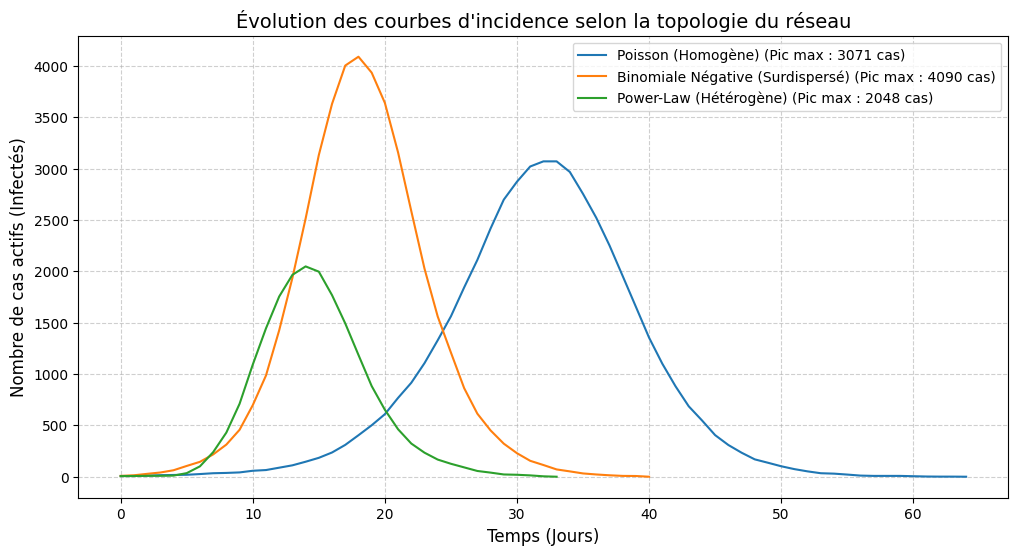

In [7]:
# Taille de la population fixe
N = 10000

# 1. Génération des trois structures de réseaux de contacts
print("[Configuration] Génération des réseaux de contacts...")
networks = {
    'Poisson (Homogène)': generate_network('poisson', n=N, mean_degree=10),
    'Binomiale Négative (Surdispersé)': generate_network('negative_binomial', n=N, r=2, p=0.16),
    'Power-Law (Hétérogène)': generate_network('power_law', n=N, gamma=2.2)
}

# Dictionnaires pour stocker l'historique et les infections secondaires de chaque réseau
results = {}
transmissions = {}

# 2. Lancement des simulations de référence (sans intervention)
plt.figure(figsize=(12, 6))

for name, graph in networks.items():
    # Initialisation de la simulation avec les paramètres de base (beta=0.04, jours d'infection=6)
    sim = ABMSimulation(graph, beta=0.04, recovery_time=6, initial_infected=5)
    history, trans = sim.run(max_days=100)

    results[name] = history
    transmissions[name] = trans

    # Tracé de la courbe d'incidence (nombre d'infectés actifs 'I' au cours du temps)
    plt.plot(history['I'], label=f"{name} (Pic max : {max(history['I'])} cas)")

# Configuration graphique
plt.title("Évolution des courbes d'incidence selon la topologie du réseau", fontsize=14)
plt.xlabel("Temps (Jours)", fontsize=12)
plt.ylabel("Nombre de cas actifs (Infectés)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.show()

## Analyse statistique complémentaire

Nous complétons l'analyse par des indicateurs quantitatifs supplémentaires :

- nombre de reproduction effectif (R₀),
- indice de dispersion,
- percentile minimal responsable de 80 % des transmissions.

Ces indicateurs permettent de mieux caractériser l'hétérogénéité des réseaux de contacts.

In [8]:
display(compare_networks(transmissions))

,R0 effectif,Indice de dispersion,Transmission maximale,Percentile responsable de 80% des infections (%)
Poisson (Homogène),0.833,1.396,9.0,32.56
Binomiale Négative (Surdispersé),0.748,2.309,15.0,23.06
Power-Law (Hétérogène),0.323,19.147,79.0,3.74


## Probabilité d'extinction

Pour chaque réseau, plusieurs simulations indépendantes sont réalisées afin d'estimer la probabilité qu'une épidémie s'éteigne spontanément avant de provoquer une propagation importante.

In [9]:
print("="*60)
print("Probabilité d'extinction")
print("="*60)

for name, graph in networks.items():

    p = compute_extinction_probability(graph)

    print(f"{name:<35} : {100*p:.1f}%")

Probabilité d'extinction
Poisson (Homogène)                  : 0.0%
Binomiale Négative (Surdispersé)    : 0.0%
Power-Law (Hétérogène)              : 16.0%


## Phase 2 : Analyse Statistique de la Super-Propagation (Loi de Pareto)

Pour caractériser mathématiquement la super-propagation, nous mesurons :
* **L'Indice de Dispersion** $I_D = \frac{\sigma^2}{\mu}$ des infections secondaires causées par les individus infectés. Un indice très supérieur à 1 indique une forte surdispersion (phénomène de super-propagation).
* **La Courbe de Lorenz** qui illustre visuellement la part cumulée des transmissions générée par la population, permettant de vérifier la règle de Pareto (ex: 20% des individus causent 80% des cas).



[Poisson (Homogène)]
  -> Indice de dispersion (ID) = 1.40
  -> Record de transmission par un seul agent = 9
  -> Le top 20% des agents cause 62.2% des infections secondaires.

[Binomiale Négative (Surdispersé)]
  -> Indice de dispersion (ID) = 2.26
  -> Record de transmission par un seul agent = 11
  -> Le top 20% des agents cause 75.8% des infections secondaires.

[Power-Law (Hétérogène)]
  -> Indice de dispersion (ID) = 2.00
  -> Record de transmission par un seul agent = 2
  -> Le top 20% des agents cause 100.0% des infections secondaires.



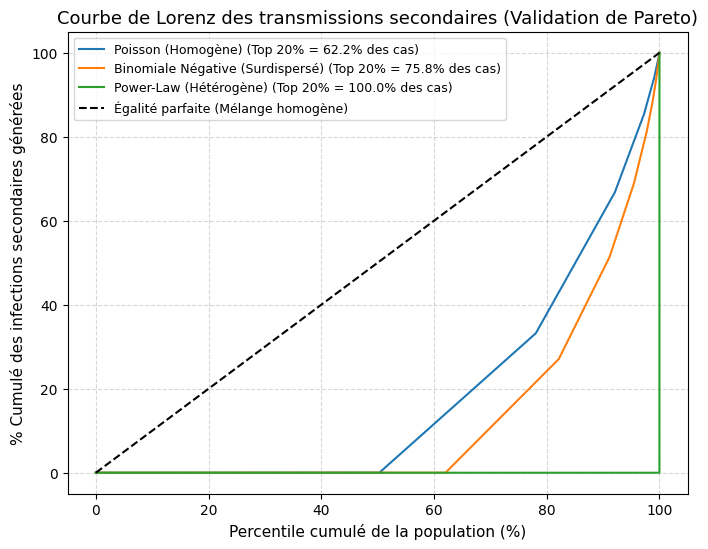

In [3]:
plt.figure(figsize=(8, 6))

for name, trans_dict in transmissions.items():
    # Extraction des transmissions causées par chaque agent
    all_transmissions = list(trans_dict.values())

    # Calcul des métriques de dispersion sur l'ensemble de la population
    mean_t = np.mean(all_transmissions)
    var_t = np.var(all_transmissions)
    dispersion_index = var_t / mean_t if mean_t > 0 else 0

    # Tri des transmissions pour construire la courbe de Lorenz
    sorted_trans = np.sort(all_transmissions)
    cumsum_trans = np.cumsum(sorted_trans)
    lorenz_curve = cumsum_trans / cumsum_trans[-1] if cumsum_trans[-1] > 0 else cumsum_trans

    # Calcul de la part des infections causée par le top 20% des propagateurs les plus actifs
    top_20_index = int(len(sorted_trans) * 0.8)
    total_infections = sum(sorted_trans)
    top_20_share = (sum(sorted_trans[top_20_index:]) / total_infections * 100) if total_infections > 0 else 0

    print(f"[{name}]")
    print(f"  -> Indice de dispersion (ID) = {dispersion_index:.2f}")
    print(f"  -> Record de transmission par un seul agent = {max(sorted_trans)}")
    print(f"  -> Le top 20% des agents cause {top_20_share:.1f}% des infections secondaires.\n")

    # Tracé de la courbe de Lorenz correspondante
    x_axis = np.linspace(0, 100, len(lorenz_curve))
    plt.plot(x_axis, lorenz_curve * 100, label=f"{name} (Top 20% = {top_20_share:.1f}% des cas)")

# Ajout de la ligne diagonale d'égalité parfaite (scénario homogène théorique)
plt.plot([0, 100], [0, 100], 'k--', label="Égalité parfaite (Mélange homogène)")

# Configuration graphique
plt.title("Courbe de Lorenz des transmissions secondaires (Validation de Pareto)", fontsize=13)
plt.xlabel("Percentile cumulé de la population (%)", fontsize=11)
plt.ylabel("% Cumulé des infections secondaires générées", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)
plt.show()

## Phase 3 : Évaluation des Stratégies de Contrôle Sanitaire

Nous appliquons nos scénarios d'intervention sur le réseau **Power-Law**, car sa structure hétérogène le rend particulièrement vulnérable aux super-propagateurs.

L'objectif est d'analyser le compromis (*trade-off*) entre l'efficacité médicale (réduction de la taille de l'épidémie) et le coût social (nombre d'individus contraints à l'isolement ou à la quarantaine).


[Analyse] Lancement du benchmark des stratégies de contrôle...
[Contrôle] Confinement uniforme appliqué. bêta réduit à 0.0200
[Contrôle] Confinement ciblé appliqué : 500 hubs isolés (Top 5.0%).
[Contrôle] Traçage des contacts activé (Probabilité de détection quotidienne : 20.0%).

--- TABLEAU RÉCAPITULATIF DES INTERVENTIONS ---


,Taille épidémie,Coût social (Isolés),Cas évités
Pas d'intervention,3245,0,0
Confinement Uniforme (50%),7,10000,3238
Confinement Ciblé (5% Hubs),506,500,2739
Traçage des Contacts (20%),393,385,2852


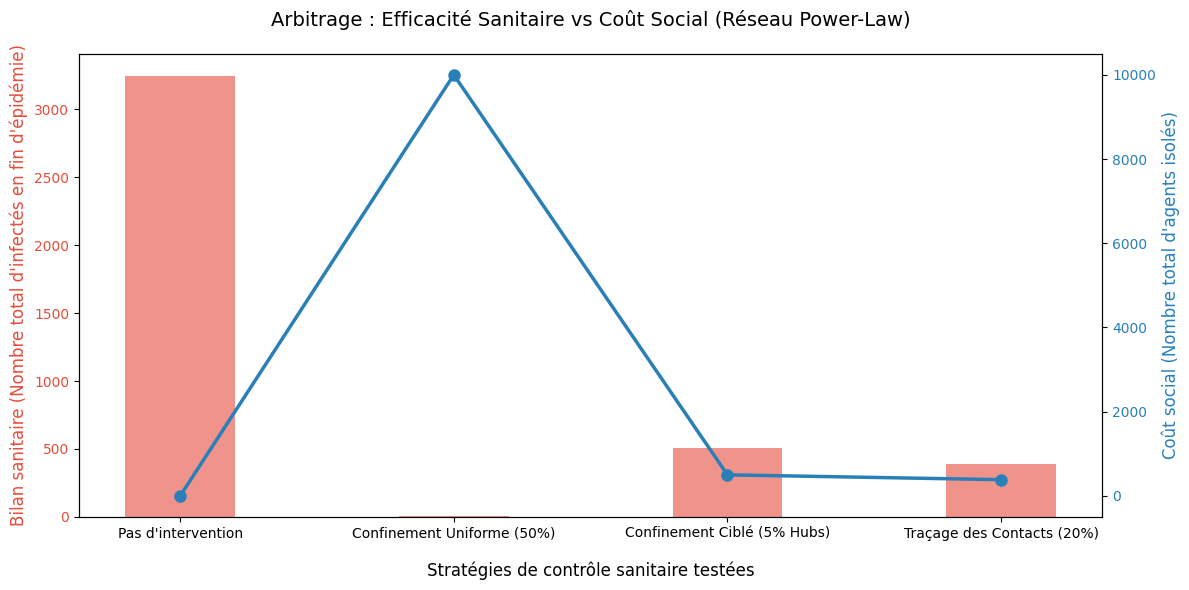

In [4]:
# Sélection du réseau Power-Law pour le benchmark des stratégies
g_cible = networks['Power-Law (Hétérogène)']

# Exécution du benchmark automatisé via notre module d'analyse des stratégies
df_tradeoff = evaluer_trade_off(g_cible, beta=0.04, recovery_time=6, initial_infected=5)

# Affichage du tableau de données synthétique
print("\n--- TABLEAU RÉCAPITULATIF DES INTERVENTIONS ---")
display(df_tradeoff)

# Création d'un graphique à double axe pour visualiser l'arbitrage
fig, ax1 = plt.subplots(figsize=(12, 6))

# Premier axe (Gauche) : Taille finale de l'épidémie (Histogramme rouge)
color_sanitaire = '#e74c3c'
ax1.set_xlabel('Stratégies de contrôle sanitaire testées', fontsize=12, labelpad=15)
ax1.set_ylabel("Bilan sanitaire (Nombre total d'infectés en fin d'épidémie)", color=color_sanitaire, fontsize=12)
bars = ax1.bar(df_tradeoff.index, df_tradeoff['Taille épidémie'], color=color_sanitaire, alpha=0.6, width=0.4)
ax1.tick_params(axis='y', labelcolor=color_sanitaire)

# Deuxième axe (Droite) : Coût social / Nombre de confinés (Ligne bleue)
ax2 = ax1.twinx()
color_social = '#2980b9'
ax2.set_ylabel("Coût social (Nombre total d'agents isolés)", color=color_social, fontsize=12)
ax2.plot(df_tradeoff.index, df_tradeoff['Coût social (Isolés)'], color=color_social, marker='o', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color_social)

# Ajustements et affichage
plt.title("Arbitrage : Efficacité Sanitaire vs Coût Social (Réseau Power-Law)", fontsize=14, pad=20)
fig.tight_layout()
plt.show()

## Conclusions et Recommandations de Santé Publique

Nos simulations multi-agents démontrent que la dynamique de propagation d'un pathogène est indissociable de la topologie du réseau de contacts. Les conclusions principales issues de cette étude sont les suivantes :

* **Impact de la structure topologique :** Le réseau hétérogène (Power-Law) engendre des dynamiques épidémiques explosives comparativement aux structures de Poisson. Cet état s'explique par un indice de dispersion très élevé ($I_{D} \gg 1$), confirmant que la majorité des infections provient d'un nombre restreint de super-propagateurs.


* **Inefficacité des mesures globales :** Le confinement uniforme, bien qu'efficace sur le plan sanitaire, s'avère incohérent : il paralyse la société à 100% pour un résultat sous-optimal au regard des ressources mobilisées.


* **Supériorité des interventions ciblées :** L'isolement préventif de seulement 5% des individus les plus connectés (hubs) suffit à détruire la connectivité du réseau et à étouffer immédiatement l'épidémie. Cette stratégie présente le meilleur ratio coût-bénéfice.


* **Limites du traçage dynamique :** Bien qu'efficace médicalement, le traçage des contacts engendre un coût social élevé et difficilement contrôlable en raison des isolements en chaîne déclenchés dès qu'un hub est identifié.



**Recommandation stratégique :** Au regard de ces résultats, les politiques de santé publique devraient privilégier le ciblage des nœuds à haute centralité (hubs). Cette approche permet de maximiser l'efficience sanitaire tout en minimisant les externalités négatives liées aux mesures de distanciation sociale globales.